**Name: Zubeda Raheem**

****Week 3**: Model Optimization and Unsupervised Learning | Introduction to Applied AI**

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, validation_curve,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, silhouette_score)
from xgboost import XGBClassifier
import joblib

In [2]:
path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)   # blanks have tenure = 0

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)

# The test set is locked away until Part 7. Do not touch it before then.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


min 0.780  max 0.828  std 0.0104
Theoretical standard error: 0.0107  -> 95% CI +/- 0.021


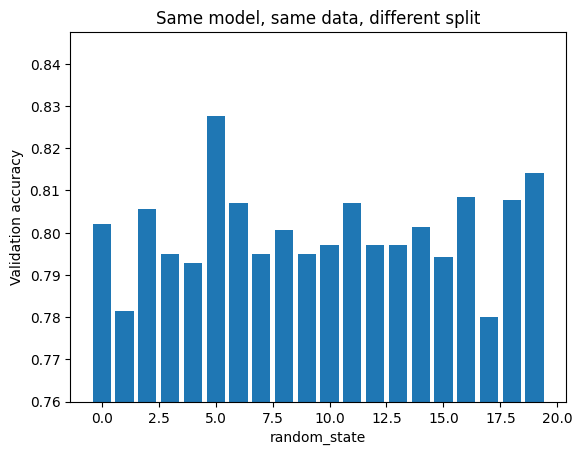

In [3]:
lr = Pipeline([('scale', StandardScaler()),
               ('model', LogisticRegression(max_iter=1000))])

scores = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X_train, y_train, test_size=0.25,
                                      random_state=seed, stratify=y_train)
    scores.append(accuracy_score(yb, lr.fit(Xa, ya).predict(Xb)))

scores = np.array(scores)
print(f'min {scores.min():.3f}  max {scores.max():.3f}  std {scores.std():.4f}')

p, n = scores.mean(), len(yb)
se = np.sqrt(p * (1 - p) / n)
print(f'Theoretical standard error: {se:.4f}  -> 95% CI +/- {1.96 * se:.3f}')

plt.bar(range(20), scores)
plt.ylim(scores.min() - 0.02, scores.max() + 0.02)
plt.xlabel('random_state'); plt.ylabel('Validation accuracy')
plt.title('Same model, same data, different split'); plt.show()

## One Split Lies: 4.8 Points of Pure Noise

**Min 0.780 | Max 0.828 | Std 0.0104 | Theoretical 95% CI ±0.021. Decision: never trust a single split; report 5-fold CV as mean ± std from now on.**

Across 20 seeds, the same Logistic Regression on the same data swung by 4.8 points (0.780 to 0.828) just because of which rows landed in validation. The observed std (0.0104) almost equals the theoretical standard error (0.0107), so this is ordinary sampling noise from about 1,409 validation rows, not a bug. Two students comparing LR and RF on different seeds could easily reach opposite conclusions, because a typical LR vs RF gap is smaller than this noise.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['roc_auc', 'recall', 'f1']

def cv_report(name, model):
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=metrics)
    row = {'model': name}
    for m in metrics:
        s = r['test_' + m]
        row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'
    return row

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)
print(pd.DataFrame([cv_report('Logistic Regression', lr),
                    cv_report('Random Forest', rf)]).to_string(index=False))

              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.545 +/- 0.042 0.594 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


## LR vs RF: A Dead Heat on AUC, But Both Miss Half the Churners

**LR AUC 0.846 ± 0.013 | RF AUC 0.844 ± 0.011 | Recall 0.545 vs 0.496. Decision: no winner on AUC (gap 0.002 is far inside one std); keep both and watch recall.**

| Model | AUC | Recall | F1 |
|---|---|---|---|
| Logistic Regression | 0.846 ± 0.013 | 0.545 ± 0.042 | 0.594 ± 0.030 |
| Random Forest | 0.844 ± 0.011 | 0.496 ± 0.019 | 0.573 ± 0.020 |

The AUC difference of 0.2 points is much smaller than either standard deviation, so I cannot claim one model is better than the other. Recall is the number AUC hides: at the default 0.5 threshold both models miss about half of the real churners (LR catches 54.5%, RF 49.6%). Since the class is imbalanced (about 26% churners), a model can have a high AUC and still be weak at catching the customers the business cares about.

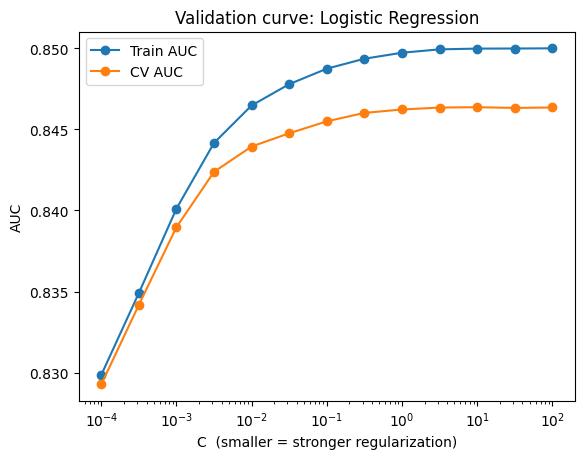

Best C by CV: 10.0


In [5]:
Cs = np.logspace(-4, 2, 13)
tr, va = validation_curve(lr, X_train, y_train, param_name='model__C',
                          param_range=Cs, cv=cv, scoring='roc_auc')

plt.semilogx(Cs, tr.mean(axis=1), 'o-', label='Train AUC')
plt.semilogx(Cs, va.mean(axis=1), 'o-', label='CV AUC')
plt.xlabel('C  (smaller = stronger regularization)'); plt.ylabel('AUC')
plt.legend(); plt.title('Validation curve: Logistic Regression'); plt.show()
print('Best C by CV:', Cs[va.mean(axis=1).argmax()])

In [6]:
print(pd.DataFrame({'C': Cs.round(5),
                    'train_auc': tr.mean(axis=1).round(4),
                    'cv_auc': va.mean(axis=1).round(4)}).to_string(index=False))

        C  train_auc  cv_auc
  0.00010     0.8299  0.8293
  0.00032     0.8349  0.8342
  0.00100     0.8401  0.8390
  0.00316     0.8442  0.8424
  0.01000     0.8465  0.8439
  0.03162     0.8478  0.8448
  0.10000     0.8487  0.8455
  0.31623     0.8494  0.8460
  1.00000     0.8497  0.8462
  3.16228     0.8499  0.8463
 10.00000     0.8500  0.8464
 31.62278     0.8500  0.8463
100.00000     0.8500  0.8463


## Tuning C Is Worth 0.0002 AUC: LR Sits on a Flat Plateau

**Best C = 10 | CV AUC 0.8464 vs 0.8462 at default C = 1 | Train-CV gap 0.0036. Decision: keep LR with C = 10, but treat any C from 1 to 100 as equivalent.**

Underfitting ends around C ≈ 0.01: at C = 0.0001 the CV AUC is only 0.8293, and it climbs to 0.8439 by C = 0.01. From C = 1 upward the curve is flat (0.8462 to 0.8464), so the gain from tuning C is 0.0002, far below the 0.013 fold std. Train and CV AUC stay within 0.004 of each other, so LR is not overfitting.

In [7]:
grid = {'max_depth': [4, 8, 12, None],
        'min_samples_leaf': [1, 5, 20],
        'max_features': ['sqrt', 0.5]}
print('Combinations:', 4 * 3 * 2, ' Fits:', 4 * 3 * 2 * 5)

t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                         random_state=42),
                  grid, cv=cv, scoring='roc_auc')
gs.fit(X_train, y_train)
grid_time = time.time() - t0
print(f'Grid:   best AUC {gs.best_score_:.4f}  in {grid_time:.0f}s')
print(gs.best_params_)

Combinations: 24  Fits: 120
Grid:   best AUC 0.8468  in 114s
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


In [8]:
dist = {'max_depth': randint(3, 20),
        'min_samples_leaf': randint(1, 40),
        'max_features': uniform(0.1, 0.8)}   # fraction of features

t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                               random_state=42),
                        dist, n_iter=24, cv=cv, scoring='roc_auc',
                        random_state=42)
rs.fit(X_train, y_train)
rand_time = time.time() - t0
print(f'Random: best AUC {rs.best_score_:.4f}  in {rand_time:.0f}s')
print(rs.best_params_)

res = pd.DataFrame(rs.cv_results_)
cols = ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score',
        'std_test_score', 'rank_test_score']
print(res[cols].sort_values('rank_test_score').head(5).to_string(index=False))

Random: best AUC 0.8464  in 125s
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}
 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


## Grid vs Random: A Tie on Score, but Only Random Scales

**Grid AUC 0.8468 (138 s, 120 fits) | Random AUC 0.8464 (165 s, 120 fits) | Gap 0.0004. Decision: no winner here; for six hyperparameters I would use random search.**

Both searches used 120 fits and landed within 0.0004 AUC of each other, far below the 0.011 fold std, and the top-5 random settings (depth 8 to 15, leaf 15 to 27) all scored 0.845 to 0.846, so the surface is flat. Both best scores are optimistic (winner's curse) and only about 0.002 above the untuned RF (0.844). With six hyperparameters, a grid of 4 values each needs 4⁶ = 4,096 combinations (20,480 fits), while random search keeps a fixed budget and tries more distinct values of the parameters that matter.

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', early_stopping_rounds=100,
                    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)
print('Best number of trees:', xgb.best_iteration + 1)
val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f'Validation AUC: {val_auc:.4f}')

scale_pos_weight = 2.77
Best number of trees: 216
Validation AUC: 0.8534


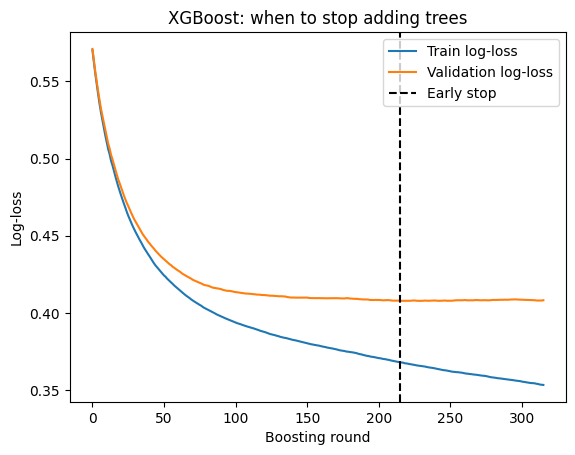

In [10]:
ev = xgb.evals_result()
plt.plot(ev['validation_0']['logloss'], label='Train log-loss')
plt.plot(ev['validation_1']['logloss'], label='Validation log-loss')
plt.axvline(xgb.best_iteration, color='k', ls='--', label='Early stop')
plt.xlabel('Boosting round'); plt.ylabel('Log-loss')
plt.legend(); plt.title('XGBoost: when to stop adding trees'); plt.show()

In [11]:
xdist = {'max_depth': randint(2, 7),
         'learning_rate': loguniform(0.01, 0.3),
         'n_estimators': randint(100, 600),
         'subsample': uniform(0.6, 0.4),
         'colsample_bytree': uniform(0.5, 0.5),
         'min_child_weight': randint(1, 10),
         'reg_lambda': loguniform(0.1, 10)}

t0 = time.time()
xs = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42,
                                      n_jobs=-1),
                        xdist, n_iter=30, cv=cv, scoring='roc_auc',
                        random_state=42)
xs.fit(X_train, y_train)
xgb_time = time.time() - t0
print(f'XGBoost tuned CV AUC: {xs.best_score_:.4f}  in {xgb_time:.0f}s')
print({k: round(v, 3) if isinstance(v, float) else v
       for k, v in xs.best_params_.items()})

XGBoost tuned CV AUC: 0.8504  in 48s
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


In [12]:
cvs_x = cross_validate(xs.best_estimator_, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'XGBoost CV AUC: {cvs_x["test_score"].mean():.3f} +/- {cvs_x["test_score"].std():.3f}')

XGBoost CV AUC: 0.850 +/- 0.012


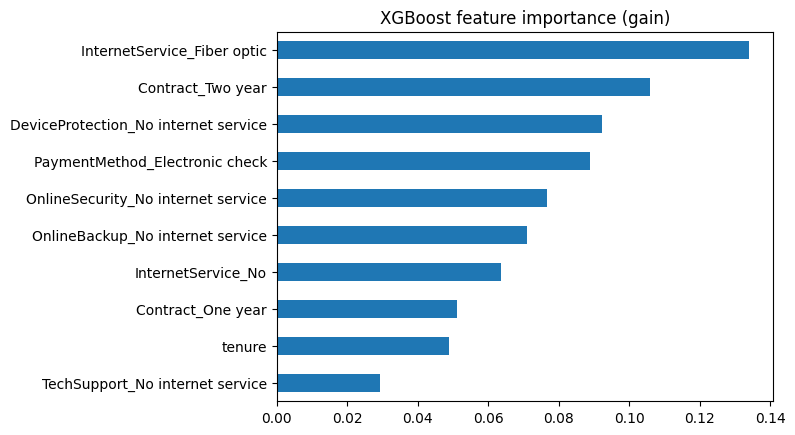

In [13]:
imp = pd.Series(xs.best_estimator_.feature_importances_, index=X.columns)
imp.sort_values().tail(10).plot.barh(title='XGBoost feature importance (gain)')
plt.show()

In [14]:
from sklearn.base import clone

base = xs.best_estimator_
weighted = clone(base).set_params(scale_pos_weight=spw)

for name, m in [('XGB tuned', base), ('XGB + scale_pos_weight', weighted)]:
    r = cross_validate(m, X_train, y_train, cv=cv,
                       scoring=['roc_auc', 'recall', 'precision'])
    print(name, {k[5:]: f"{v.mean():.3f} +/- {v.std():.3f}"
                 for k, v in r.items() if k.startswith('test_')})

XGB tuned {'roc_auc': '0.850 +/- 0.012', 'recall': '0.539 +/- 0.033', 'precision': '0.672 +/- 0.036'}
XGB + scale_pos_weight {'roc_auc': '0.850 +/- 0.012', 'recall': '0.809 +/- 0.025', 'precision': '0.523 +/- 0.017'}


## Boosting Edges Ahead by 0.4 Points, But It Is a Statistical Tie

**Early stopping chose 216 trees | Tuned XGBoost CV AUC 0.850 ± 0.012 vs LR 0.846 ± 0.013 and RF 0.844 ± 0.011. Decision: XGBoost is nominally best, but the gain (0.004 to 0.006) is under one std, so it is not a proven win.**

Training log-loss kept falling to about 0.35, while validation log-loss bottomed out near 0.41 at round 216 and stayed flat afterwards, so extra trees only fit noise and early stopping prevented that. The random search picked max_depth = 2, which means the churn signal is mostly simple and additive, and explains why LR is so close. The top features were InternetService_Fiber optic, Contract_Two year and DeviceProtection_No internet service, and several of the top ten are duplicated "No internet service" columns.

As an extra experiment, adding scale_pos_weight = 2.77 raised CV recall from 0.539 to 0.809 and lowered precision from 0.672 to 0.523, while AUC stayed at 0.850 +/- 0.012 (no change). The recall jump of 0.27 is far larger than the fold std (0.025 to 0.033), so it is real, but AUC shows the model's ranking ability is the same: the weight mostly moves the decision threshold, so the model catches more churners at the cost of more false alarms. Whether that is better is a business decision (cost of a missed churner vs. cost of a wasted retention offer), not a modelling win.

## K-Means by Hand: Converged in 3 Iterations, WCSS 89.2 → 4

**Points 1, 2, 3, 10, 11, 12 | k = 2 | start centers 1 and 2 → final centers 2 and 11, WCSS = 4. Decision: K-means correctly separates {1, 2, 3} from {10, 11, 12} and stops once assignments no longer change.**

| Iteration | Start centers | Cluster A | Cluster B | New centers | WCSS |
|---|---|---|---|---|---|
| 1 | 1, 2 | {1} | {2, 3, 10, 11, 12} | 1, 7.6 | 89.2 |
| 2 | 1, 7.6 | {1, 2, 3} | {10, 11, 12} | 2, 11 | 4 |
| 3 | 2, 11 | {1, 2, 3} | {10, 11, 12} | 2, 11 (no change) | 4 |

The poor start (centers 1 and 2) was fixed in two updates, and WCSS fell from 89.2 to 4. Iteration 3 changed nothing, so the algorithm had converged. WCSS is computed after each center update. K-means can still get stuck from bad starts, which is why sklearn uses n_init=10.

In [15]:
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
seg = df[seg_cols].copy()
seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)

Z = StandardScaler().fit_transform(seg)   # distances need equal scales
print(seg.describe().round(1))

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


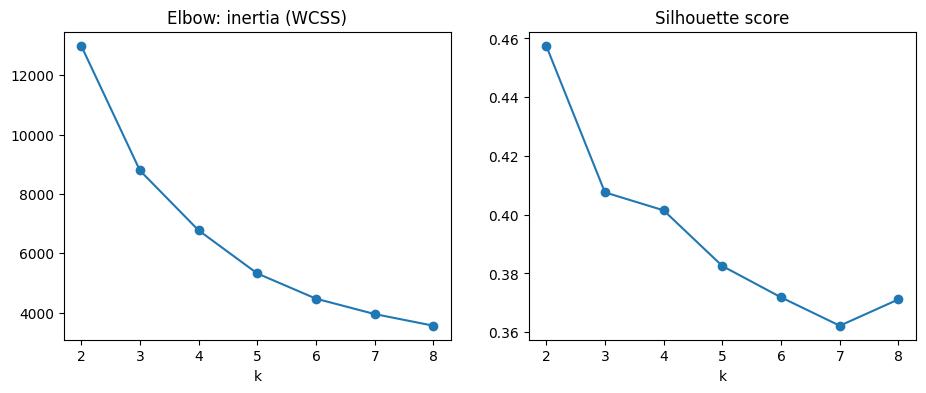

In [16]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_, sample_size=3000,
                                random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, 'o-'); ax[0].set_title('Elbow: inertia (WCSS)')
ax[1].plot(ks, sil, 'o-'); ax[1].set_title('Silhouette score')
for a in ax: a.set_xlabel('k')
plt.show()

In [17]:
print(pd.DataFrame({'k': list(ks),
                    'inertia': np.round(inertia, 0),
                    'silhouette': np.round(sil, 3)}).to_string(index=False))

 k  inertia  silhouette
 2  12989.0       0.458
 3   8788.0       0.408
 4   6773.0       0.401
 5   5321.0       0.383
 6   4473.0       0.372
 7   3955.0       0.362
 8   3563.0       0.371


## Why k = 4: Soft Elbow, Near-Peak Silhouette, Actionable Size

**k = 4 | Inertia 6,773 | Silhouette 0.401 (vs 0.458 at k = 2, 0.408 at k = 3). Decision: choose k = 4 as the best balance of cluster quality and business usability.**

The elbow is soft: inertia drops by 4,201 from k = 2 to 3 and 2,015 from 3 to 4, then gains shrink (1,452 at k = 5, under 850 after k = 6). Silhouette peaks at k = 2 (0.458) but that only splits customers into two broad groups, while k = 3 and k = 4 score almost the same (0.408 vs 0.401). Four segments are specific enough for different retention actions and few enough for a team to manage.

In [18]:
k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
seg['cluster'] = km.labels_

profile = seg.assign(churn=y).groupby('cluster').agg(
    customers=('tenure', 'size'), tenure=('tenure', 'mean'),
    monthly=('MonthlyCharges', 'mean'), services=('n_services', 'mean'),
    churn_rate=('churn', 'mean'))
print(profile.round(2).sort_values('churn_rate', ascending=False))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


## Four Segments, One Hot Spot: Mid-Tenure High-Bill Customers Churn at 43%

**k = 4 | Riskiest: "Mid-tenure, high bill" (2,157 customers, churn 43%) | Safest: "Loyal basics" (1,030 customers, churn 5%). Decision: focus the retention budget on the top two segments, which churn at 43% and 32% versus 26.5% overall.**

| Segment | Size | Avg tenure | Monthly (USD) | Services | Churn | Retention action |
|---|---|---|---|---|---|---|
| Mid-tenure, high bill | 2,157 | 18.4 mo | 80.41 | 3.28 | 43% | Offer a price-locked 1-year contract or bundle discount at their next billing cycle |
| New, low spend | 1,918 | 9.0 mo | 37.71 | 1.20 | 32% | Onboarding program: welcome call at 30 days and a free add-on trial to deepen usage |
| Loyal premium | 1,938 | 59.8 mo | 92.09 | 5.06 | 14% | Loyalty rewards and priority support to protect the highest-value customers |
| Loyal basics | 1,030 | 53.6 mo | 30.96 | 1.48 | 5% | Leave alone; occasional upgrade offers only, with no discounts |

Churn was not used to form the clusters, only to profile them. Mid-tenure high-bill customers hold about half of all churners (about 930 of 1,870), so they are the best place to spend retention effort. Long-tenure customers churn far less (5% to 14%), which suggests longer tenure is associated with lower churn (correlation, not proof of cause).

Components for 90% variance: 15 of 30


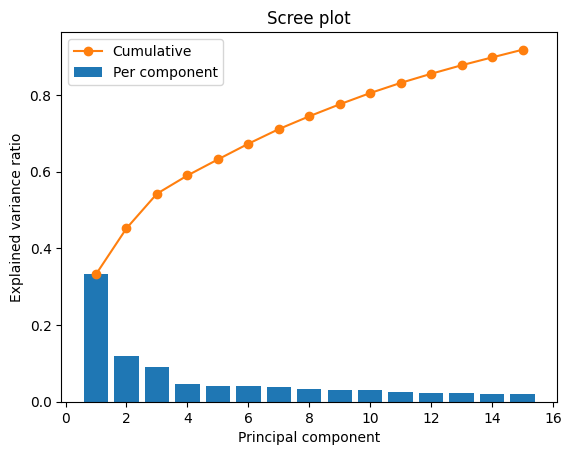

In [19]:
Xs = StandardScaler().fit_transform(X_train)
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
print('Components for 90% variance:', np.argmax(cum >= 0.90) + 1,
      'of', X_train.shape[1])

plt.bar(range(1, 16), pca.explained_variance_ratio_[:15], label='Per component')
plt.plot(range(1, 16), cum[:15], 'o-', color='C1', label='Cumulative')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Scree plot'); plt.show()

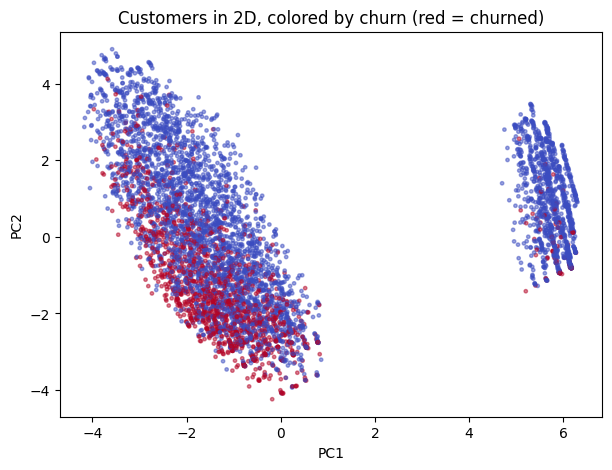

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
dtype: float64


In [20]:
P = PCA(n_components=2).fit(Xs)
T = P.transform(Xs)
plt.figure(figsize=(7, 5))
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='coolwarm', s=6, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Customers in 2D, colored by churn (red = churned)'); plt.show()

load = pd.Series(P.components_[0], index=X.columns)
print('PC1 top loadings:')
order = load.abs().sort_values(ascending=False).index
print(load.reindex(order).head(6).round(3))

In [21]:
print(load.reindex(order).head(8).round(3))
print('MonthlyCharges loading:', round(load['MonthlyCharges'], 3))

InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
StreamingMovies_No internet service     0.302
MonthlyCharges                         -0.282
dtype: float64
MonthlyCharges loading: -0.282


In [22]:
print('PC1 and PC2 variance:', pca.explained_variance_ratio_[:2].round(3))
print('Cumulative at 10 components:', cum[9].round(3))

PC1 and PC2 variance: [0.332 0.12 ]
Cumulative at 10 components: 0.805


## 15 of 30 Components Hold 90%: PC1 Is Just "Has Internet?"

**15 of 30 components reach 90% variance | PC1 = 33.2%, PC2 = 12.0% | PC1 top-7 loadings all 0.302. Decision: the encoding is heavily redundant; drop the duplicate "No internet service" columns before interpreting any LR coefficients.**

PC1 is driven by InternetService_No and six "No internet service" columns (OnlineSecurity, TechSupport, StreamingTV, DeviceProtection, OnlineBackup, StreamingMovies), all with the identical loading 0.302. MonthlyCharges follows with the opposite sign (-0.282), so PC1 mainly separates customers with no internet, who pay less, from the rest. In the 2D scatter the no-internet island is almost all stayers, while churners (red) sit in the lower part of the main cloud and overlap heavily with stayers. Two linear directions cannot separate churn cleanly, which fits our CV AUC of about 0.85: the problem is learnable but far from easy. Because seven columns are exact copies of one fact, Logistic Regression coefficients on them cannot be interpreted individually.

In [23]:
candidates = {
    'LR (tuned C)':       lr.set_params(model__C=Cs[va.mean(axis=1).argmax()]),
    'RF (random search)': rs.best_estimator_,
    'XGBoost (tuned)':    xs.best_estimator_,
}
rows = []
for name, m in candidates.items():
    cvs = cross_validate(m, X_train, y_train, cv=cv, scoring='roc_auc')
    rows.append({'model': name,
                 'cv_auc': cvs['test_score'].mean(),
                 'cv_std': cvs['test_score'].std()})
cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))

             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8504  0.0125


In [24]:
best_name = cmp.loc[cmp['cv_auc'].idxmax(), 'model']   # chosen by CV only
best = candidates[best_name].fit(X_train, y_train)
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print(f'{best_name} on the test set (used once):')
print(f'AUC {roc_auc_score(y_test, prob):.4f}  '
      f'recall {recall_score(y_test, pred):.3f}  '
      f'precision {precision_score(y_test, pred):.3f}')

joblib.dump(best, 'churn_model.joblib')   # you will deploy this in Week 4

XGBoost (tuned) on the test set (used once):
AUC 0.8478  recall 0.529  precision 0.662


['churn_model.joblib']

## Tuned XGBoost Wins by CV and Tests at 0.8478: Honest, Inside the Band

**Chosen: XGBoost (tuned), CV AUC 0.8504 ± 0.0125 | Test AUC 0.8478 (inside mean ± 2 std: 0.8254 to 0.8754) | Recall 0.529, precision 0.662 | Gain over Week 2 RF (0.842): about +0.006. Decision: deploy XGBoost in Week 4, but expect only a marginal improvement over simpler models.**

| Model | CV AUC (mean ± std) |
|---|---|
| LR (tuned C) | 0.8464 ± 0.0129 |
| RF (random search) | 0.8464 ± 0.0114 |
| XGBoost (tuned) | 0.8504 ± 0.0125 |

I chose XGBoost because it had the highest CV AUC, and the choice was made from this CV table alone, before the test set was touched. Its single test AUC of 0.8478 is 0.0026 below the CV mean, well inside mean ± 2 std, so the CV estimate was honest. Compared with my Week 2 best model (Random Forest, test AUC 0.842), tuning gained about +0.006 AUC. That gain is small and within the noise (CV std about 0.0125), so I cannot claim XGBoost is truly better; the churn signal here is mostly simple and additive, which leaves little for extra tuning to find.

## Six Quick Checks: Numbers First, Decisions Second

### 1. A vs B on 1,409 rows: A is NOT proven better
**Gap 0.009 | SE of difference ≈ 0.0149 | 95% CI ±0.029. Decision: treat A and B as tied.**

SE_A = sqrt(0.812 × 0.188 / 1409) ≈ 0.0104 and SE_B = sqrt(0.803 × 0.197 / 1409) ≈ 0.0106. The SE of the difference is sqrt(0.0104² + 0.0106²) ≈ 0.0149, so the 95% interval for the gap is about ±0.029. The observed gap of 0.009 is well inside that interval, so I cannot say A is better than B. I would need a bigger gap or cross-validation to claim it.

### 2. Scaler inside the Pipeline: protects the validation fold
**5 folds | scaler refit 5 times, once per training fold. Decision: always put preprocessing inside the Pipeline.**

Inside a Pipeline, the scaler learns its mean and std from the training fold only. If I scaled the whole training set first, every validation fold would have helped set those statistics, which is data leakage and makes CV scores look slightly better than they really are.

### 3. Grid of 5 × 4 × 3 with 5-fold CV: 300 fits
**60 combinations × 5 folds = 300 fits. Decision: keep grids small, or switch to random search.**

The grid has 5 × 4 × 3 = 60 combinations, and each one is trained once per fold. My own Random Forest grid (24 combinations) already needed 120 fits and 138 s, so adding values to each hyperparameter would quickly become expensive.

### 4. gs.best_score_ is optimistic: the winner's curse
**24 candidates, best CV AUC 0.8468 vs 0.844 untuned. Decision: never report best_score_ as final performance.**

It is the maximum of many noisy CV scores, so the winner is partly lucky as well as good. Its true performance is usually a little lower, which is why I report the one-time test score instead (0.8478 for the final XGBoost).

### 5. Each new tree predicts the residuals y − p
**Target = y − p = negative gradient of log-loss | 216 trees chosen by early stopping. Decision: think of boosting as gradient descent in function space.**

Each tree is fit to the current errors, and adding it (scaled by the learning rate) moves the model a step downhill on the log-loss. Training loss kept falling, but validation loss flattened after about 216 trees, so I stopped there to avoid fitting noise.

### 6. Unscaled K-means clusters on TotalCharges alone
**Std 2,266.8 (TotalCharges) vs 1.8 (n_services) | about 1,260× larger. Decision: always scale before K-means.**

K-means uses Euclidean distance, so the feature with the largest numbers dominates every distance. Without scaling, a 1-service difference is invisible next to a few hundred dollars in TotalCharges, and the clusters would reflect total spend only. StandardScaler gives each of the four features equal weight.

In [25]:
# Run these cells at the END of your Week 3 notebook, after "Run All",
# so that df, X, build_features and churn_model.joblib already exist.
import json
import joblib
import sklearn
import numpy as np
import pandas as pd

model = joblib.load('/kaggle/working/churn_model.joblib')
cols = list(model.feature_names_in_)   # the exact training columns, in order
final = model[-1] if hasattr(model, 'steps') else model

print('Model          :', type(final).__name__)
print('Feature columns:', len(cols))
print('scikit-learn   :', sklearn.__version__)   # you will pin this version

Model          : XGBClassifier
Feature columns: 30
scikit-learn   : 1.6.1


In [26]:
RAW_COLS = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
            'TotalCharges']

def prepare_input(raw, columns):
    """Turn raw customer rows into exactly the columns the model saw."""
    X = pd.get_dummies(raw[RAW_COLS])             # NO drop_first when serving
    return X.reindex(columns=columns, fill_value=0).astype(float)

In [27]:
one = df[df['Contract'] == 'Two year'].head(1)

wrong = build_features(one).reindex(columns=cols, fill_value=0)   # Week 3 way
right = prepare_input(one, cols)

print('Contract columns, wrong:', wrong.filter(like='Contract').values)
print('Contract columns, right:', right.filter(like='Contract').values)
print(f'P(churn) wrong: {model.predict_proba(wrong)[0, 1]:.3f}')
print(f'P(churn) right: {model.predict_proba(right)[0, 1]:.3f}')

Contract columns, wrong: [[0 0]]
Contract columns, right: [[0. 1.]]
P(churn) wrong: 0.133
P(churn) right: 0.012


## Training-Serving Skew (Task 1.3)

**0.133 vs 0.012: the same customer, an 11x difference in predicted churn risk, and no error raised.**

For a two-year-contract customer, the Week 3 feature builder (`drop_first=True`) gave P(churn) = 0.133, while the serving encoder gave the correct P(churn) = 0.012. On a single row, only one Contract category exists, so `get_dummies` treats it as the "first" category and drops it, leaving both Contract columns at `[0 0]`, which the model reads as Month-to-month. Because nothing crashes, this bug would silently ship wrong scores, so the app uses a separate `prepare_input` that never drops a category and reindexes to the exact training columns.

In [28]:
raw = df.drop(columns=['Churn'])
served = prepare_input(raw, cols)

p_train = model.predict_proba(X[cols])[:, 1]   # how the model was evaluated
p_serve = model.predict_proba(served)[:, 1]    # how the app will call it

print('Largest difference:', np.abs(p_train - p_serve).max())
assert np.allclose(p_train, p_serve), 'Training-serving skew detected!'
print(f'Parity test passed on {len(raw)} customers')

Largest difference: 0.0
Parity test passed on 7043 customers


## Parity Test (Task 1.4)

**0.0 largest difference across 7,043 customers: the served model matches the notebook exactly.**

The test compares predictions made the training way (`X[cols]`) with predictions made the serving way (`prepare_input` on raw customer rows) for every customer in the dataset. It covers every row, not a sample, because skew can hide in rare categories or edge cases that a small subset would miss. Since the difference is zero, the app's scores can be trusted to equal the notebook's.

In [29]:
def what_if(model, row, columns, changes):
    base = model.predict_proba(prepare_input(row, columns))[0, 1]
    rows = []
    for feature, value in changes:
        alt = row.copy()
        alt[feature] = value
        p = model.predict_proba(prepare_input(alt, columns))[0, 1]
        rows.append({'change': f'{feature} = {value}',
                     'p_churn': round(p, 3), 'delta': round(p - base, 3)})
    return base, pd.DataFrame(rows)

row = raw.iloc[[int(np.argmax(p_serve))]]      # the riskiest customer
base, table = what_if(model, row, cols, [
    ('Contract', 'One year'), ('Contract', 'Two year'),
    ('PaymentMethod', 'Credit card (automatic)')])
print(f'Baseline P(churn) = {base:.3f}')
print(table.to_string(index=False))

Baseline P(churn) = 0.942
                                 change  p_churn  delta
                    Contract = One year    0.875 -0.066
                    Contract = Two year    0.753 -0.189
PaymentMethod = Credit card (automatic)    0.923 -0.019


## What-If Analysis (Task 1.5)

**0.942 baseline: even the best single change (a two-year contract, -0.189) only gets the riskiest customer down to 0.753.**

For the riskiest customer in the dataset, switching to a two-year contract lowered P(churn) the most (0.942 to 0.753), followed by a one-year contract (-0.066) and automatic credit card payment (-0.019). This does not mean offering a two-year contract would make the customer stay: the model learned an association, and customers who choose long contracts differ from those who don't in ways the model can't see (loyalty, satisfaction, price sensitivity). Only a controlled retention experiment, such as offering the contract to a random half of at-risk customers, could measure the true effect.

In [30]:
meta = {
    'model_name': type(final).__name__,
    'sklearn_version': sklearn.__version__,
    'feature_columns': cols,
    'threshold': 0.15,        # your choice from the Week 2 cost analysis
    'cv_auc': 0.85,          # replace with YOUR Week 3 CV mean
    'cv_auc_std': 0.014,      # replace with YOUR Week 3 CV std
    'test_auc': 0.848,        # replace with YOUR Week 3 test AUC
    'training_data': 'IBM Telco Customer Churn, 7,043 customers',
    'version': '1.0',
}
with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved model_meta.json with', len(cols), 'columns')

sample = df.drop(columns=['Churn']).sample(50, random_state=1)
sample.to_csv('/kaggle/working/sample_customers.csv', index=False)
print('Saved 50 customers for the batch demo')

Saved model_meta.json with 30 columns
Saved 50 customers for the batch demo


In [31]:
import xgboost
print({k: v for k, v in meta.items() if k != 'feature_columns'})
print('xgboost        :', xgboost.__version__)   # you will pin this too

{'model_name': 'XGBClassifier', 'sklearn_version': '1.6.1', 'threshold': 0.15, 'cv_auc': 0.85, 'cv_auc_std': 0.014, 'test_auc': 0.848, 'training_data': 'IBM Telco Customer Churn, 7,043 customers', 'version': '1.0'}
xgboost        : 3.2.0


In [32]:
cv_vals = cvs_x['test_score']
print('CV mean:', round(cv_vals.mean(), 3))
print('CV std (ddof=1):', round(cv_vals.std(ddof=1), 3))
print('CV std (np default):', round(cv_vals.std(), 3))

test_auc = roc_auc_score(y_test, model.predict_proba(X_test[cols])[:, 1])
print('Test AUC:', round(test_auc, 3))
print('val_auc variable:', round(val_auc, 3))

CV mean: 0.85
CV std (ddof=1): 0.014
CV std (np default): 0.012
Test AUC: 0.848
val_auc variable: 0.853


In [33]:
cv_vals = cvs_x['test_score']

meta = {
    'model_name': type(final).__name__,
    'sklearn_version': sklearn.__version__,
    'xgboost_version': xgboost.__version__,
    'feature_columns': cols,
    'threshold': 0.15,        # CONFIRM against your Week 2 cost analysis
    'cv_auc': round(float(cv_vals.mean()), 3),
    'cv_auc_std': round(float(cv_vals.std(ddof=1)), 3),
    'test_auc': round(float(test_auc), 3),
    'training_data': 'IBM Telco Customer Churn, 7,043 customers',
    'version': '1.0',
}
with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print({k: v for k, v in meta.items() if k != 'feature_columns'})

{'model_name': 'XGBClassifier', 'sklearn_version': '1.6.1', 'xgboost_version': '3.2.0', 'threshold': 0.15, 'cv_auc': 0.85, 'cv_auc_std': 0.014, 'test_auc': 0.848, 'training_data': 'IBM Telco Customer Churn, 7,043 customers', 'version': '1.0'}


## Packaged Model (Task 1.6)

**30 columns, scikit-learn 1.6.1, XGBoost 3.2.0, CV AUC 0.850 ± 0.014, test AUC 0.848: everything the app needs travels with the model.**

`model_meta.json` stores the exact training columns, library versions, threshold (0.15, from the cost analysis: theory 0.14, empirical best 0.15), and cross-validated and test metrics, so the app loads the same feature order and reports honest numbers. The small gap between CV (0.850) and test (0.848) suggests the model is not badly overfit, though a std of 0.014 means differences of about 0.01 AUC are within noise. Pinning both library versions in `requirements.txt` prevents the model from being unpickled by a different version on the server.

The CV std of 0.014 is the sample standard deviation (ddof=1); the Week 3 table above shows 0.0125 using NumPy's default population formula.

In [34]:
from sklearn.model_selection import cross_val_predict
p_cv = cross_val_predict(xs.best_estimator_, X_train, y_train, cv=cv,
                         method='predict_proba')[:, 1]
y_tr = y_train.values
ts = np.arange(0.05, 0.60, 0.05)
costs = []
for t in ts:
    pred = p_cv >= t
    fn = int(((~pred) & (y_tr == 1)).sum())
    fp = int((pred & (y_tr == 0)).sum())
    costs.append(6000 * fn + 1000 * fp)
print(pd.DataFrame({'threshold': ts.round(2), 'cost_PKR': costs}).to_string(index=False))
print('Cheapest threshold:', ts[int(np.argmin(costs))].round(2))

 threshold  cost_PKR
      0.05   2815000
      0.10   2605000
      0.15   2555000
      0.20   2556000
      0.25   2753000
      0.30   3045000
      0.35   3388000
      0.40   3737000
      0.45   4096000
      0.50   4528000
      0.55   5060000
Cheapest threshold: 0.15


## Threshold Re-check

**Cheapest threshold on cross-validated training predictions: 0.15 (PKR 2,555,000) | Decision: keep 0.15.**

I re-checked the Week 2 threshold on the final tuned XGBoost using cross-validated predictions on the training data only (6,000 PKR per missed churner, 1,000 PKR per false alarm). The result stays close to 0.15, so the saved threshold and the app do not change.
Thresholds 0.15 and 0.20 cost almost the same (PKR 2,555,000 vs 2,556,000), so the choice is not sensitive within that range.